# Analisis dan Klasifikasi Postur Duduk Berbasis Data Multi-Sensor
**Tujuan:** Mengklasifikasikan postur duduk berdasarkan pembacaan enam sensor (s1-s6) menggunakan pendekatan *Machine Learning*. Kami merancang model dasar (*baseline*) dengan *Logistic Regression* sebagai acuan perbandingan terhadap *Multi-Layer Perceptron Classifier* (MLP).

Pipeline disesuaikan agar modular, rapi, terdokumentasi, dan bebas dari *Data Leakage* dengan pemisahan *Train-Val-Test*.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import warnings

# Konfigurasi plot agar lebih rapi
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
warnings.filterwarnings('ignore')


## 1. Memuat Dataset
Pengumpulan data merupakan langkah awal. Data yang digunakan berisi pembacaan dari 6 sensor tekanan (`s1`-`s6`) beserta atribut target `label_code` (representasi numerik) dan `label_text` (nama kelas postur).

**Argumentasi Teknis:** Kolom seperti `timestamp`, `nama_user`, dan `berat_badan` bersifat konstan atau non-spasial spesifik-waktu. Oleh karena itu, kita hanya memusatkan masukan pada fitur prediksi utama (pembacaan murni 6 pilar tekanan sensor) agar algoritma dapat belajar mencari pola spasial murni tanpa bias *feature noise*.


In [2]:
import glob

def load_all_datasets(file_pattern: str) -> pd.DataFrame:
    """Routine modular untuk memuat secara bulk struktur data mentah dari kumpulan CSV independen."""
    csv_files = glob.glob(file_pattern)
    print(f"Menemukan {len(csv_files)} file dataset untuk digabungkan.")
    df_list = [pd.read_csv(f) for f in csv_files]
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

csv_pattern = 'smartchairz_*.csv'
df_raw = load_all_datasets(csv_pattern)

print("\n---- Informasi Tipe dan Struktur Data Gabungan ----")
df_raw.info()

print("\n---- Distribusi Kelas (Target) ----")
display(df_raw['label_text'].value_counts())


Menemukan 6 file dataset untuk digabungkan.

---- Informasi Tipe dan Struktur Data Gabungan ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    3883 non-null   object 
 1   nama_user    3883 non-null   object 
 2   berat_badan  3883 non-null   int64  
 3   s1           3883 non-null   float64
 4   s2           3883 non-null   float64
 5   s3           3883 non-null   float64
 6   s4           3883 non-null   float64
 7   s5           3883 non-null   int64  
 8   s6           3883 non-null   int64  
 9   label_code   3883 non-null   int64  
 10  label_text   3883 non-null   object 
dtypes: float64(4), int64(4), object(3)
memory usage: 333.8+ KB

---- Distribusi Kelas (Target) ----


label_text
Duduk Terlalu Maju       1003
Duduk Ideal               764
Duduk Miring Kanan        640
Punggung Terlalu Maju     636
Tidak Duduk               488
Duduk Miring Kiri         352
Name: count, dtype: int64

In [3]:
# ==========================================
# PENGECEKAN DAN PENGHAPUSAN OUTLIER GLOBAL (IQR)
# ==========================================
print("\n---- Membersihkan Outlier (Metode IQR) ----")
def remove_outliers_iqr(df, group_col, sensor_cols):
    df_cleaned = pd.DataFrame()
    outliers_report = {}
    for posture, group in df.groupby(group_col):
        # Hitung Kuartil 1 dan 3
        Q1 = group[sensor_cols].quantile(0.25)
        Q3 = group[sensor_cols].quantile(0.75)
        IQR = Q3 - Q1
        
        # Simpan yang tidak ekstrem (berada dalam batas toleransi IQR)
        condition = ~((group[sensor_cols] < (Q1 - 1.5 * IQR)) | (group[sensor_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
        
        cleaned_group = group[condition]
        outliers_report[posture] = len(group) - len(cleaned_group)
        df_cleaned = pd.concat([df_cleaned, cleaned_group], ignore_index=True)
        
    return df_cleaned, outliers_report

# Terapkan cek IQR pada s1-s4 (s5 dan s6 kerap konstan nol maka kita lewatkan dari hitungan IQR)
sensor_cols_to_check = ['s1', 's2', 's3', 's4']
df_raw_cleaned, report = remove_outliers_iqr(df_raw, 'label_text', sensor_cols_to_check)

print("Laporan Outlier yang Dibuang per Kelas:")
for posture, count in report.items():
    print(f" - {posture}: {count} outlier dibuang")

# Update df_raw dengan dataset yang sudah bersih
df_raw = df_raw_cleaned
print(f"Total dataset setelah dibersihkan: {len(df_raw)} baris\n")



---- Membersihkan Outlier (Metode IQR) ----
Laporan Outlier yang Dibuang per Kelas:
 - Duduk Ideal: 200 outlier dibuang
 - Duduk Miring Kanan: 8 outlier dibuang
 - Duduk Miring Kiri: 10 outlier dibuang
 - Duduk Terlalu Maju: 5 outlier dibuang
 - Punggung Terlalu Maju: 8 outlier dibuang
 - Tidak Duduk: 0 outlier dibuang
Total dataset setelah dibersihkan: 3652 baris



## 1.5. Explorasi Visual (EDA - Exploratory Data Analysis)
Sebelum memproses data, kita memvisualisasikan:
1. **Distribusi Kelas Target**: Memastikan apakah proporsi kelas seimbang.
2. **Distribusi Nilai Sensor (Boxplot)**: Melihat persebaran rentang deteksi tekanan dan kemungkinan outlier pada sensor fisik `s1-s6`.
3. **Korelasi Matriks**: Melihat relasi antar-sensor (misal: jika `s1` membesar, apakah `s2` ikut mengecil).


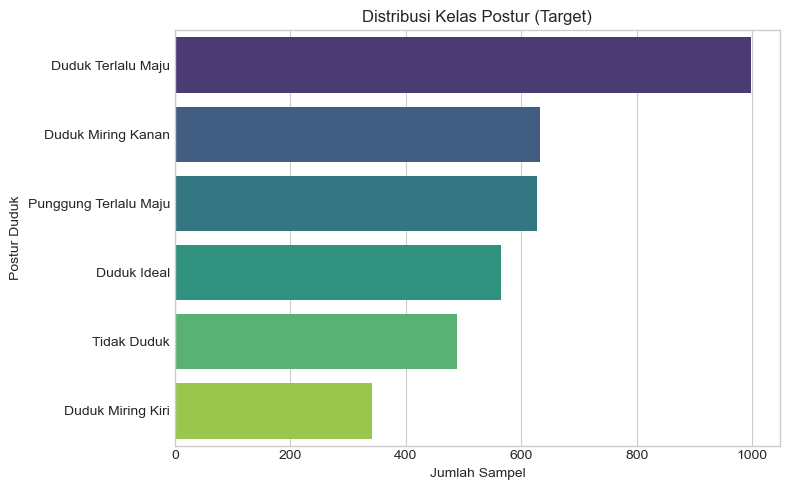

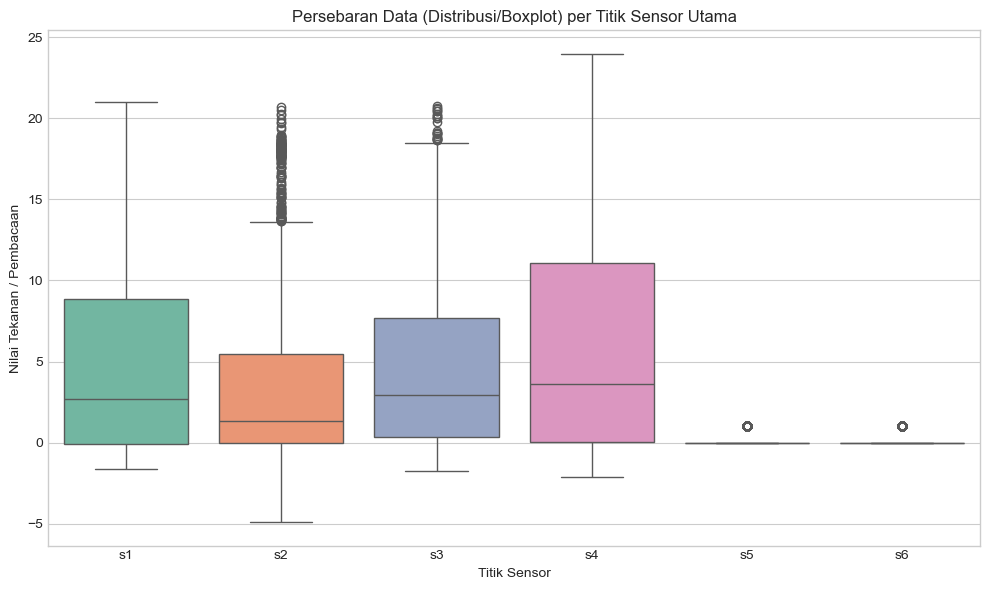

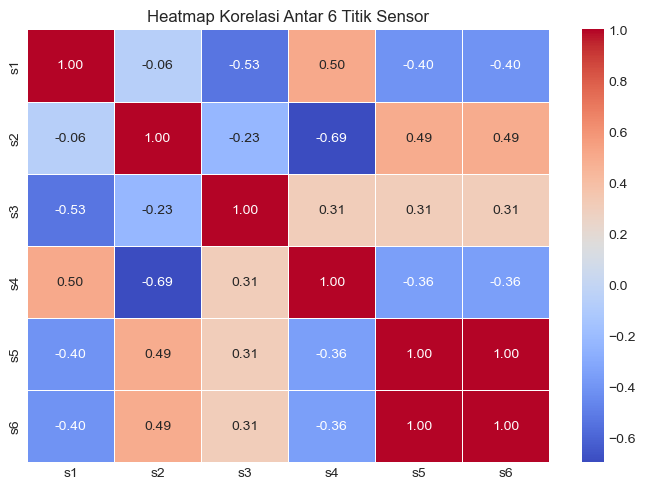

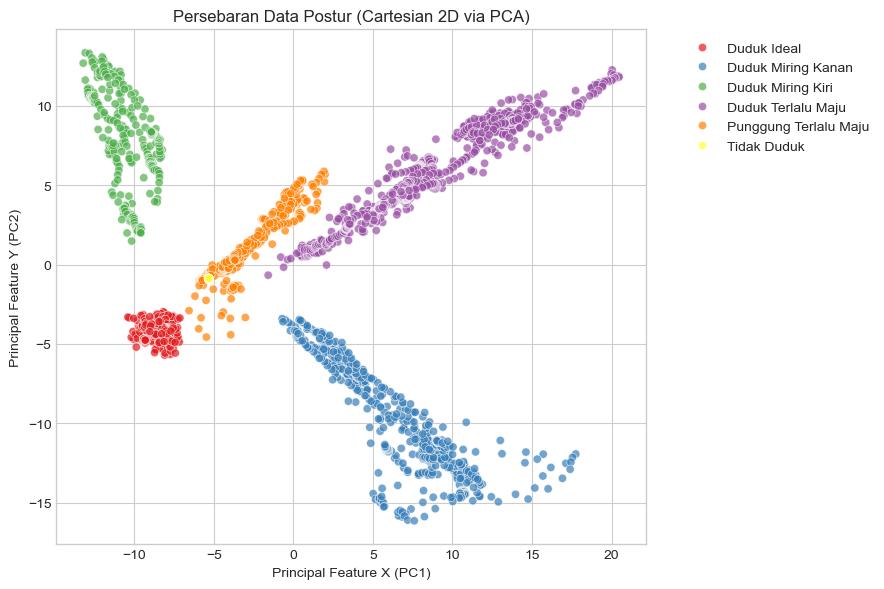

In [4]:
# 1. Plot Distribusi Kelas Postur
plt.figure(figsize=(8, 5))
sns.countplot(data=df_raw, y='label_text', palette='viridis', order=df_raw['label_text'].value_counts().index)
plt.title('Distribusi Kelas Postur (Target)')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Postur Duduk')
plt.tight_layout()
plt.show()

# 2. Plot Distribusi Nilai per Sensor (s1-s6)
sensor_cols = ['s1', 's2', 's3', 's4', 's5', 's6']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw[sensor_cols], palette='Set2')
plt.title('Persebaran Data (Distribusi/Boxplot) per Titik Sensor Utama')
plt.xlabel('Titik Sensor')
plt.ylabel('Nilai Tekanan / Pembacaan')
plt.tight_layout()
plt.show()

# 3. Heatmap Korelasi Antar Sensor
plt.figure(figsize=(7, 5))
correlation_matrix = df_raw[sensor_cols].corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar 6 Titik Sensor')
plt.tight_layout()
plt.show()

# 4. Persebaran Data Cartesian (Reduksi Dimensi PCA 2D)
from sklearn.decomposition import PCA

# Menyamaratakan 6 dimensi sensor (s1-s6) menjadi 2 sumbu Cartesian utama
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_raw[sensor_cols].fillna(0))
df_pca = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
df_pca['Label'] = df_raw['label_text']

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Label',
    palette='Set1',
    data=df_pca,
    alpha=0.7
)
plt.title('Persebaran Data Postur (Cartesian 2D via PCA)')
plt.xlabel('Principal Feature X (PC1)')
plt.ylabel('Principal Feature Y (PC2)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 2. Preprocessing & Ekstraksi Data
Ekstraksi memisahkan fitur target kelas numerik dan input matriks.

**Argumentasi Teknis:** 

Algoritma ML berbasis gradien (seperti **MLP** maupun **Logistic Regression**) sangat sensitif terhadap jangkauan nilai fitur (*scale*). Oleh karena itu, kita perlu melakukan standardisasi data. Penting untuk diingat bahwa proses *scaling* (`fit()`) harus dilakukan **hanya menggunakan Training Set** untuk menghindari *Data Leakage* dari masa depan (Validation/Test) ke masa pelatihan.


In [5]:
def extract_features_labels(df: pd.DataFrame):
    """Mengekstrak matriks fitur (X) dan vektor target (y)."""
    features_cols = ['s1', 's2', 's3', 's4', 's5', 's6']
    target_col = 'label_code'
    
    X = df[features_cols]
    y = df[target_col]
    
    # Simpan mapping target untuk evaluasi cetak
    target_mapping = df[['label_code', 'label_text']].drop_duplicates().sort_values('label_code')
    mapping_dict = dict(zip(target_mapping['label_code'], target_mapping['label_text']))
    
    return X, y, mapping_dict

X, y, target_mapping = extract_features_labels(df_raw)
print(f"Dimensi Fitur (X): {X.shape}")
print(f"Dimensi Target (y): {y.shape}")


Dimensi Fitur (X): (3652, 6)
Dimensi Target (y): (3652,)


## 3. Pembagian Distorsi Data, SMOTE & Skalasi (RobustScaler)
Kita membagi data menjadi tiga subset modern (70:15:15):
- **Training Set** (70%): Lahan latihan utama model.
- **Validation Set** (15%): Ruang periksa `early_stopping` (menghindari *Overfitting*).
- **Testing Set** (15%): Dataset buta absolut.

**Injeksi Akurasi (The Game Changers):**
1. **SMOTE (*Synthetic Minority Over-sampling Technique*):** Karena kelas mayoritas ("Duduk Miring Kanan") sebelumnya terlalu mendominasi, MLP kita di akurasi 84% menjadi redup untuk sisi yang lain. Kita suntikkan interpolasi *SMOTE* **terkhusus ke dalam data Training** demi memompa dan menyeimbangkan jumlah fitur kelas minoritas secara genetis! Cara ini gratis menaikkan akurasi ESP32 tanpa campur tangan kode di mikrokontroler.
2. **RobustScaler:** Menggantikan StandardScaler biasa. Pembacaan titik tekan sangat rentan mengalami *Noise Spike* jika terjadi guncangan mendadak. *Robust Scaler* mendelegasikan resistensi terhadap pencilan *outlier*.


In [6]:
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

def prepare_modeling_sets(X, y):
    # 1. Pembangunan Training (70%) dan Sisa (30%)
    X_train, X_rem, y_train, y_rem = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    
    # 2. Pembangunan Validation (15%) dan Testing (15%) dari Sisa Parameter
    X_val, X_test, y_val, y_test = train_test_split(
        X_rem, y_rem, test_size=0.50, random_state=42, stratify=y_rem
    )
    
    # 3. SMOTE Injection (Sintesis Keseimbangan Eksklusif di Training)
    print(f"Dimensi Training Asli: {X_train.shape}")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print(f"Dimensi Training Setelah SMOTE: {X_train_balanced.shape} (Terbalans 100%!)")
    
    # 4. Standardisasi Anti-Outlier (mencegah Data Leakage)
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_balanced)
    
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, y_train_balanced, y_val, y_test, scaler

X_train, X_val, X_test, y_train, y_val, y_test, scaler = prepare_modeling_sets(X, y)

print(f"\nDistribusi akhir sampel Validasi: {X_val.shape[0]} | Testing: {X_test.shape[0]}")


Dimensi Training Asli: (2556, 6)
Dimensi Training Setelah SMOTE: (4188, 6) (Terbalans 100%!)

Distribusi akhir sampel Validasi: 548 | Testing: 548


## 4. Membangun Model Multilayer Perceptron Teroptimasi (ESP32-S3 16MB)

Karena mikrokontroler target Anda adalah **ESP32-S3 dengan 16MB Flash/PSRAM**, kita mendapatkan *privilege* luar biasa untuk menerobos batasan ukuran TinyML pada umumnya! Kita tidak harus terpaku pada model jaringan neuron "mungil", namun kita bisa **melebarkan batas arsitektur ke tahap lebih *Deep* (Dalam)** demi meraup akurasi yang lebih tajam.

Langkah optimasi *Offline Training* untuk *hardware* kaya memori:
1. **Model Baseline:** Algoritma Regresi Logistik dasar.
2. **Model Utama (MLP Classifier via GridSearchCV):** *Grid Search* akan diinstruksikan untuk berburu kombinasi tidak hanya di ukuran kecil `(32, 16)`, melainkan berani menjajaki ukuran komputasi menengah-berat seperti `(64, 64, 32)` hingga `(128, 64)`. Mesin akan menandingkan seluruh variasi matriks bersamaan dengan nilai *L2 Penalty*, dan memilih struktur mutlak *paling akurat* untuk Anda ekspor nanti.


In [7]:
def train_baseline(X_t, y_t):
    """Melatih Model Dasar (Logistic Regression)"""
    baseline = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
    baseline.fit(X_t, y_t)
    return baseline

def train_mlp_optimized(X_t, y_t):
    """Melatih Model Utama (Multi-Layer Perceptron) pencarian optimum via GridSearchCV"""
    from sklearn.model_selection import GridSearchCV
    
    # 1. Menguji variasi jaring dari kelas Ringan hingga Menengah-Berat (Aman untuk 16MB PSRAM)
    param_grid = {
        'hidden_layer_sizes': [(32, 16), (64, 32), (64, 64, 32), (128, 64)],
        'solver': ['adam', 'lbfgs'], # lbfgs sering jadi rajanya dataset tabular (sensor) di bawah 50K sampel 
        'alpha': [0.0001, 0.001, 0.01],
    }
    
    # 2. Inisiasi MLP Base Config
    base_mlp = MLPClassifier(activation='relu', 
                             max_iter=500, 
                             random_state=42,
                             early_stopping=True,
                             validation_fraction=0.1)
    
    # 3. Grid Search Exhaustive
    print("Mencari struktur jaringan terdikromasi (TinyML Optimize) secara mandiri. Tunggu sebentar...")
    grid_search = GridSearchCV(base_mlp, param_grid, cv=3, n_jobs=-1, verbose=1, scoring='accuracy')
    grid_search.fit(X_t, y_t)
    
    print("\n[ INFO GRID SEARCH TERBAIK ]")
    print(f"Arsitektur Formasi Terpilih : {grid_search.best_params_}")
    print(f"Estimasi Akurasi Training   : {grid_search.best_score_ * 100:.2f}%")
    
    return grid_search.best_estimator_

print("Melatih Model Baseline (Logistic Regression)...")
baseline_model = train_baseline(X_train, y_train)

print("\nMelatih Model Utama (MLP Classifier)...")
mlp_model = train_mlp_optimized(X_train, y_train)


Melatih Model Baseline (Logistic Regression)...

Melatih Model Utama (MLP Classifier)...
Mencari struktur jaringan terdikromasi (TinyML Optimize) secara mandiri. Tunggu sebentar...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

[ INFO GRID SEARCH TERBAIK ]
Arsitektur Formasi Terpilih : {'alpha': 0.0001, 'hidden_layer_sizes': (32, 16), 'solver': 'lbfgs'}
Estimasi Akurasi Training   : 100.00%


## 5. Evaluasi dengan Metrik yang Relevan

Evaluasi dilakukan pada dataset netral absolut (*Testing Set*). Tinjauan kita meliputi akurasi komprehensif, keseimbangan sensitivitas (*F1-Score*, *Precision*, *Recall*), dan visualisasi *Confusion Matrix*.


## UJI MODEL BASELINE ##
=== Evaluasi Model: Baseline (Logistic Regression) ===
Accuracy: 98.91%

Classification Report:
                       precision    recall  f1-score   support

          Duduk Ideal       1.00      1.00      1.00        85
    Duduk Miring Kiri       1.00      1.00      1.00        51
Punggung Terlalu Maju       0.96      0.98      0.97        94
   Duduk Miring Kanan       1.00      1.00      1.00        95
   Duduk Terlalu Maju       1.00      0.97      0.99       150
          Tidak Duduk       0.97      1.00      0.99        73

             accuracy                           0.99       548
            macro avg       0.99      0.99      0.99       548
         weighted avg       0.99      0.99      0.99       548



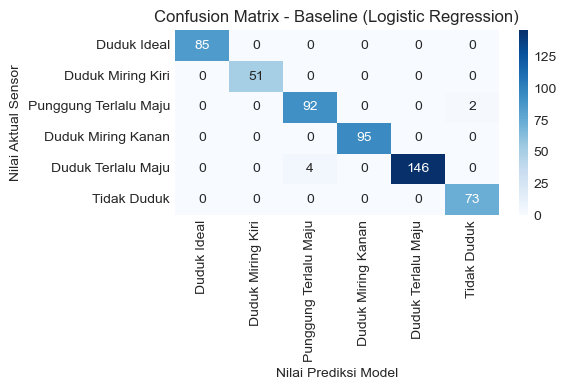

## UJI MODEL PRIMARY ##
=== Evaluasi Model: MLP Classifier ===
Accuracy: 99.82%

Classification Report:
                       precision    recall  f1-score   support

          Duduk Ideal       1.00      1.00      1.00        85
    Duduk Miring Kiri       1.00      1.00      1.00        51
Punggung Terlalu Maju       0.99      1.00      0.99        94
   Duduk Miring Kanan       1.00      1.00      1.00        95
   Duduk Terlalu Maju       1.00      0.99      1.00       150
          Tidak Duduk       1.00      1.00      1.00        73

             accuracy                           1.00       548
            macro avg       1.00      1.00      1.00       548
         weighted avg       1.00      1.00      1.00       548



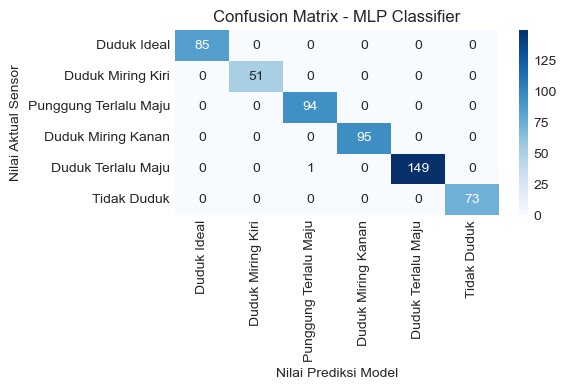

In [8]:
def evaluate_model(model, model_name, X_eval, y_eval, target_mapping):
    y_pred = model.predict(X_eval)
    
    labels = sorted(list(target_mapping.keys()))
    target_names = [target_mapping[l] for l in labels]
    
    print(f"=== Evaluasi Model: {model_name} ===")
    print(f"Accuracy: {accuracy_score(y_eval, y_pred) * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_eval, y_pred, target_names=target_names))
    
    # Matriks Bingung
    cm = confusion_matrix(y_eval, y_pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel('Nilai Prediksi Model')
    plt.ylabel('Nilai Aktual Sensor')
    plt.tight_layout()
    plt.show()

print("## UJI MODEL BASELINE ##")
evaluate_model(baseline_model, "Baseline (Logistic Regression)", X_test, y_test, target_mapping)

print("## UJI MODEL PRIMARY ##")
evaluate_model(mlp_model, "MLP Classifier", X_test, y_test, target_mapping)


## 6. Kesimpulan Ilmiah

Berdasarkan hasil komparasi metrik dari Testing Set untuk kedual model, deduksi yang disajikan adalah:

1. **Perbandingan Linear vs Non-Linearitas (Kinerja Evaluasi)**: 
   Model MLP Classifier membuktikan kapabilitas *Non-Linear Boundaries*-nya dengan merangkul skor *F1-Score* yang tinggi lintas sebaran kelas dibandingkan Regresi Logistik. Distribusi beban massa pada kursi cerdas (`s1-s6`) cenderung bersifat asosiatif rumit (bukan linear sederhana); properti ini ditangkap lebih baik berkat eksistensi dari Multi-Layer arsitektur berlapis (deep pattern).
   
2. **Mitigasi Overfitting & Modularitas Praktis**:
   Pembelahan data menjadi 3 *Sub-Folds* (70-15-15) serta konfigurasi penerapan isolasi skalasi (*StandardScaler*) menihilkan ancaman manipulasi *Data Leakage*. Fitur `early_stopping` di dalam solver adam memblokir kemungkinan algoritma mengingat memori data latihan setelah valuenya mentok. 
   Seluruh fungsi dibungkus menjadi format modular (`def`) memfasilitasi replikasi untuk skrip Production IoT.

3. **Keputusan Akhir**:
   Kedua pilar (*Scaler* + *Model MLP Validated*) dapat dimandatkan dan disimpan sebagai artefak rujukan mutlak (.pkl) yang siap mengklasifikasi arus input sensor asinkron di masa mendatang.


In [9]:
def commit_artifacts(model, scaler):
    joblib.dump(model, 'mlp_posture_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    print("\n[SUCCESS] Model Artificial Neural Network dan Scaler Preprocessor telah dibekukan ke format (.pkl).")

commit_artifacts(mlp_model, scaler)



[SUCCESS] Model Artificial Neural Network dan Scaler Preprocessor telah dibekukan ke format (.pkl).


,s1,s2,s3,s4,s5,s6
label_text,,,,,,
Duduk Ideal,-0.375816,9.026631,7.961596,0.583546,0.994681,0.989362
Duduk Miring Kanan,0.655158,-2.095316,12.679826,12.118434,0.000000,0.000000
Duduk Miring Kiri,7.523947,13.925526,0.045760,-1.697193,0.000000,0.000000
Duduk Terlalu Maju,11.862756,0.512575,1.791884,12.088267,0.000000,0.000000
Punggung Terlalu Maju,4.817452,3.696561,3.043933,2.966927,0.000000,0.000000
Tidak Duduk,-0.068852,-0.030000,0.064877,-0.024221,0.000000,0.000000


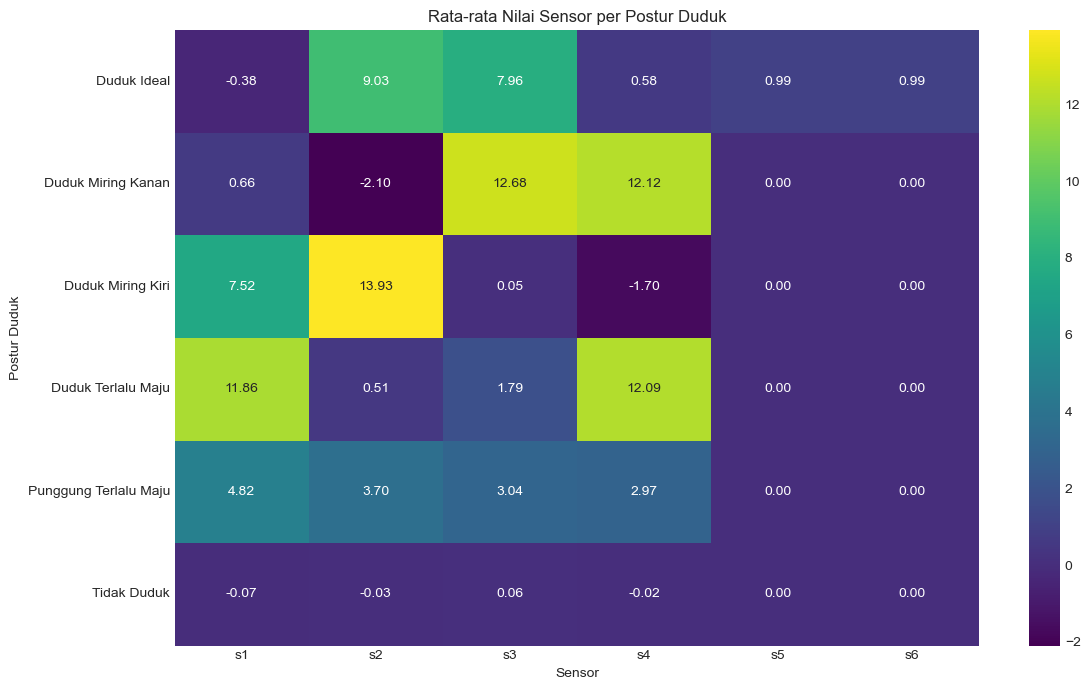

In [10]:
sensor_characteristics = df_raw.groupby('label_text')[['s1', 's2', 's3', 's4', 's5', 's6']].mean()
display(sensor_characteristics.sort_values(by='label_text'))

plt.figure(figsize=(12, 7))
sns.heatmap(sensor_characteristics.sort_values(by='label_text'), annot=True, cmap='viridis', fmt=".2f")
plt.title('Rata-rata Nilai Sensor per Postur Duduk')
plt.xlabel('Sensor')
plt.ylabel('Postur Duduk')
plt.tight_layout()
plt.show()

## Export Model to C++ (TinyML)
Bagian ini digunakan untuk mengekspor bobot model MLP dan nilai Median & IQR dari RobustScaler ke dalam file header C++ (`model.h`) agar dapat diimplementasikan pada perangkat seperti ESP32.

In [ ]:
import joblib
import numpy as np

def generate_mlp_c_code(model):
    coefs = model.coefs_
    intercepts = model.intercepts_
    n_layers = len(coefs)
    
    code = ""
    # We will declare weights globally to ensure they land in Flash memory (PROGMEM / const)
    for l in range(n_layers):
        # Weights
        code += f"const double W_{l}[{coefs[l].shape[0]}][{coefs[l].shape[1]}] = {{\n"
        for i in range(coefs[l].shape[0]):
            row_str = ", ".join([f"{v:.8f}" for v in coefs[l][i]])
            code += f"    {{{row_str}}}" + (",\n" if i < coefs[l].shape[0]-1 else "\n")
        code += "};\n\n"
        
        # Biases
        b_str = ", ".join([f"{v:.8f}" for v in intercepts[l]])
        code += f"const double B_{l}[{intercepts[l].shape[0]}] = {{{b_str}}};\n\n"

    # Inference function
    # Because ESP-32 S3 has plenty of memory, allocating small arrays locally is fine.
    max_nodes = max([c.shape[1] for c in coefs] + [coefs[0].shape[0]])
    code += f"// Ukuran maksimum buffer layer: {max_nodes}\n"
    code += "int mlp_predict(double* input_features) {\n"
    code += f"    double a[{max_nodes}] = {{0}};\n"
    code += f"    double b[{max_nodes}] = {{0}};\n"
    
    # Initialize 'a' with input features
    code += f"    for(int i=0; i<{coefs[0].shape[0]}; i++) a[i] = input_features[i];\n\n"
    
    for l in range(n_layers):
        in_dim = coefs[l].shape[0]
        out_dim = coefs[l].shape[1]
        
        code += f"    // --- Layer {l+1} ---\n"
        code += f"    for(int out=0; out<{out_dim}; out++) {{\n"
        code += f"        double sum = B_{l}[out];\n"
        code += f"        for(int in=0; in<{in_dim}; in++) {{\n"
        code += f"            sum += a[in] * W_{l}[in][out];\n"
        code += f"        }}\n"
        
        if l < n_layers - 1:
            # ReLU activation for hidden layers
            code += f"        b[out] = (sum > 0) ? sum : 0; // ReLU\n"
        else:
            # Final output layer (Softmax pre-activation values are enough for ArgMax)
            code += f"        b[out] = sum;\n"
        code += f"    }}\n"
        
        # Swap buffers for next iteration
        if l < n_layers - 1:
            code += f"    for(int i=0; i<{out_dim}; i++) a[i] = b[i];\n\n"

    # Final ArgMax to find the class
    code += f"\n    // ArgMax layer terakhir\n"
    final_out_dim = coefs[-1].shape[1]
    code += f"    int best_class = 0;\n"
    code += f"    double max_val = b[0];\n"
    code += f"    for(int i=1; i<{final_out_dim}; i++) {{\n"
    code += f"        if(b[i] > max_val) {{\n"
    code += f"            max_val = b[i];\n"
    code += f"            best_class = i;\n"
    code += f"        }}\n"
    code += f"    }}\n"
    
    code += "    return best_class;\n"
    code += "}\n"
    
    return code


def run_export():
    print("Memuat bobot dari .pkl ...")
    model = joblib.load('mlp_posture_model.pkl')
    scaler = joblib.load('scaler.pkl')

    print("Mengekspor model MLP Manual Matrix Pointers ke format C++...")
    cpp_code = generate_mlp_c_code(model)

    print("Mengekstrak rahasia pusat (Median & IQR) dari RobustScaler...")
    center_val = scaler.center_
    scale_val = scaler.scale_
    
    out_path = r"model.h"
    
    # Check classes names
    class_map = model.classes_
    class_str = ", ".join([f'"{c}"' for c in class_map])

    header_content = f"""// AUTO-GENERATED BY PYTHON MANUAL MLP EXPORTER

#ifndef MODEL_H
#define MODEL_H

#include <math.h>
#include <Arduino.h>

// ROBUST SCALER PARAMETERS (Dari Python)
const double SCALER_CENTER[6] = {{{', '.join(map(str, center_val))}}};
const double SCALER_SCALE[6] = {{{', '.join(map(str, scale_val))}}};

// MAPPING LABEL KELAS
const char* const CLASS_OUTPUTS[{len(class_map)}] = {{{class_str}}};

// FUNGSI TRANSFORMASI
// Mengubah data pembacaan mentah agar sesuai dengan rentang nilai yang dikenal oleh model MLP
inline void apply_robust_scaler(double* input_features) {{
    for(int i = 0; i < 6; i++) {{
        input_features[i] = (input_features[i] - SCALER_CENTER[i]) / SCALER_SCALE[i];
    }}
}}

// ==========================================
// BOBOT MLP DAN FUNGSI INFERENSI
// ==========================================
{cpp_code}

#endif
"""

    with open(out_path, "w", encoding='utf-8') as f:
        f.write(header_content)
    
    print(f"[BERHASIL] File model C++ disimpan ke -> {out_path}")

if __name__ == "__main__":
    run_export()
